In [48]:
import os
import re
import time
import math
import json
import requests
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx

from shapely.geometry import LineString, Point, MultiLineString
from shapely.geometry.polygon import Polygon

from shapely.ops import linemerge

warnings.filterwarnings("ignore", category=UserWarning)

## __Polygon AMG__

In [49]:
AMG_Polygon = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Importacion TransCAD/Limites Municipales/AMG/AMG_SHAPE.shp')
print("original AMG_Polygon CRS:", AMG_Polygon.crs)
AMG_Polygon = AMG_Polygon.to_crs(epsg=4326)
print("AMG_Polygon CRS after transformation:", AMG_Polygon.crs)

original AMG_Polygon CRS: EPSG:4019
AMG_Polygon CRS after transformation: EPSG:4326


## __Network: DRIVE__
- solo para ver los valores que existen en la columna HIGHWAY de una red que solo trae links viales (donde transitan vehiculos)
- network_type = DRIVE no trae cicleway, footway, etc.

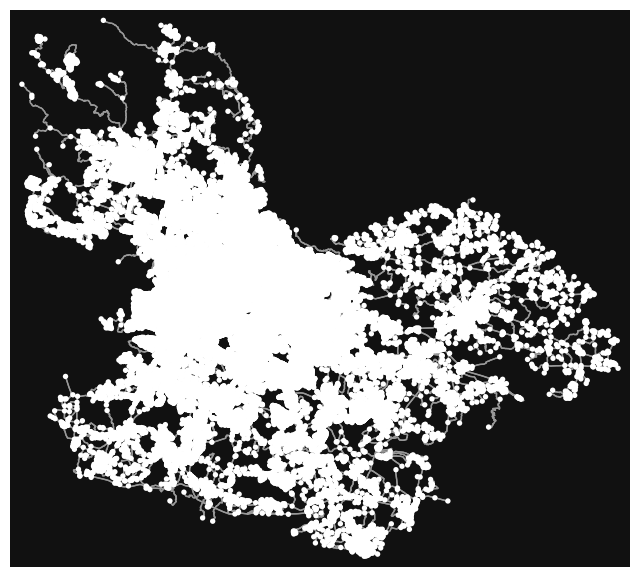

In [50]:
G_drive = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    network_type="drive",
    simplify=True,
    retain_all=False,
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_drive)
nodes_drive, edges_drive = ox.graph_to_gdfs(G_drive, nodes=True, edges=True)

In [51]:
edges = edges_drive.copy()
edges.reset_index(inplace=True, drop=True)

highway_types_drive = edges['highway'].astype(str).unique()
highway_types_drive

array(['motorway', 'motorway_link', 'trunk', 'trunk_link', 'tertiary',
       'primary', 'unclassified', 'residential', 'secondary',
       'secondary_link', 'living_street', 'primary_link',
       "['residential', 'living_street']", 'tertiary_link',
       "['residential', 'unclassified']",
       "['primary_link', 'trunk_link']", "['motorway_link', 'secondary']",
       "['primary', 'trunk']", 'busway', "['tertiary_link', 'tertiary']",
       'ladder', "['tertiary', 'trunk_link']",
       "['tertiary', 'motorway_link']", "['residential', 'tertiary']",
       "['tertiary', 'secondary']", "['unclassified', 'living_street']",
       "['unclassified', 'tertiary']", "['residential', 'trunk_link']",
       "['secondary_link', 'secondary']",
       "['residential', 'motorway_link']", "['motorway', 'trunk']",
       "['unclassified', 'trunk_link']",
       "['unclassified', 'primary_link']"], dtype=object)

## __Network: ALL__

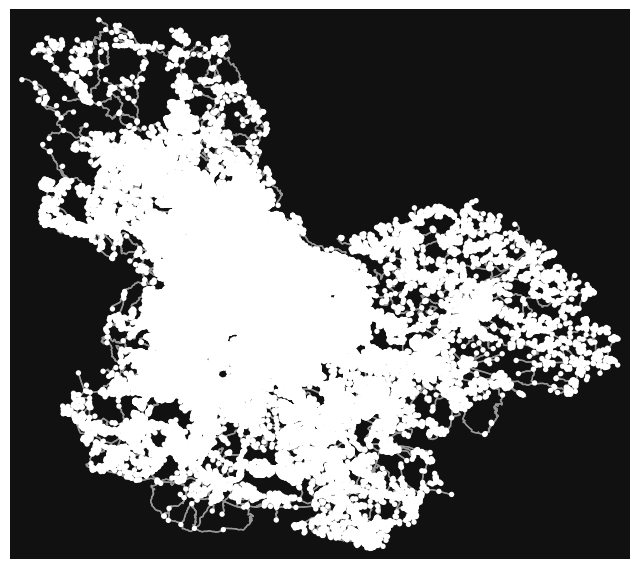

In [52]:
G_all = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    network_type="all",
    simplify=True,
    retain_all=False,
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_all)
nodes_vial, edges_vial = ox.graph_to_gdfs(G_all, nodes=True, edges=True)

In [61]:
nodes_vial

,y,x,street_count,highway,railway,ref,junction,geometry
osmid,,,,,,,,
267537966,20.616062,-103.246323,3,NaN,NaN,NaN,NaN,POINT (-103.24632 20.61606)
267538751,20.605647,-103.136397,3,NaN,NaN,NaN,NaN,POINT (-103.1364 20.60565)
273140976,20.607581,-103.131846,3,NaN,NaN,NaN,NaN,POINT (-103.13185 20.60758)
296347106,20.471190,-103.261200,3,NaN,NaN,NaN,NaN,POINT (-103.2612 20.47119)
296347259,20.452284,-103.249527,3,NaN,NaN,NaN,NaN,POINT (-103.24953 20.45228)
...,...,...,...,...,...,...,...,...
13675767585,20.676749,-103.341854,1,NaN,NaN,NaN,NaN,POINT (-103.34185 20.67675)
13675767590,20.675586,-103.341958,3,NaN,NaN,NaN,NaN,POINT (-103.34196 20.67559)
13675767594,20.675592,-103.341976,3,NaN,NaN,NaN,NaN,POINT (-103.34198 20.67559)


## __Network: RAILWAY (Tren Ligero)__

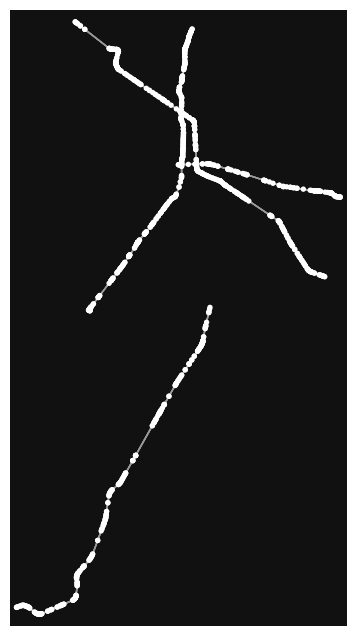

In [53]:
rail_filter = (
    '["railway"~"light_rail|subway|rail"]'
    '["name"~"Línea 1 del Tren Eléctrico Urbano|'
    'Linea 1 del Tren Eléctrico Urbano|'
    'Línea 2 del Tren Eléctrico Urbano|'
    'Linea 2 del Tren Eléctrico Urbano|'
    'Línea 3 del Tren Eléctrico Urbano|'
    'Linea 3 del Tren Eléctrico Urbano|'
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara|'
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara"]'
)

G_rail_uns = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    custom_filter=rail_filter,
    simplify=False, #AQUI si false para mantener todas las estaciones
    retain_all=True, #TRUE porque las 4 lineas no estan conectadas entre si
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_rail_uns)
nodes_rail, edges_rail = ox.graph_to_gdfs(G_rail_uns, nodes=True, edges=True)

In [62]:
nodes_rail

,y,x,street_count,railway,geometry
osmid,,,,,
294101514,20.710914,-103.355886,2,NaN,POINT (-103.35589 20.71091)
294101519,20.706091,-103.354795,2,NaN,POINT (-103.3548 20.70609)
294101528,20.693145,-103.354011,2,NaN,POINT (-103.35401 20.69315)
294101532,20.678643,-103.354247,2,NaN,POINT (-103.35425 20.67864)
294101533,20.677498,-103.354719,2,NaN,POINT (-103.35472 20.6775)
...,...,...,...,...,...
12837540170,20.726487,-103.353234,2,NaN,POINT (-103.35323 20.72649)
12837540171,20.723517,-103.353121,2,NaN,POINT (-103.35312 20.72352)
12837540172,20.723516,-103.353165,2,NaN,POINT (-103.35317 20.72352)


## __ALL + RAILWAY__

In [79]:
G_base = nx.compose(G_all, G_rail_uns)
nodes_base, edges_base = ox.graph_to_gdfs(G_base, nodes=True, edges=True)

## __Get a graph with only driveable links to be used in the snap of BUS STOPS ONLY!__

In [80]:
G_snap = G_base.copy()

valid_highways = {
    'motorway',
    'motorway_link',
    'trunk',
    'trunk_link',
    'primary',
    'primary_link',
    'secondary',
    'secondary_link',
    'tertiary',
    'tertiary_link',
    'residential',
    'unclassified',
    'service',
}

#if it has one of these, remove
unvalid_walkable_highways = {
    'footway',
    'pedestrian',
    'path',
    'steps',
    'busway'
}

# Lista para guardar links a eliminar
edges_remove = []

# Recorrer todos los links
for u, v, k, data in G_snap.edges(keys=True, data=True):

    hwy = data.get("highway")

    # Caso highway es lista
    if isinstance(hwy, list):
        # Si contiene algún tipo no válido, eliminar
        if any(h in unvalid_walkable_highways for h in hwy):
            edges_remove.append((u, v, k))
        # Si no contiene ninguno válido, eliminar
        if not any(h in valid_highways for h in hwy):
            edges_remove.append((u, v, k))

    # Caso highway es texto
    elif isinstance(hwy, str):
        if hwy not in valid_highways:
            edges_remove.append((u, v, k))

    # Si no tiene atributo highway
    else:
        edges_remove.append((u, v, k))


### __Footway (mostly) edges to ignore for STOP SNAPPING__

In [81]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_snap.edge_subgraph(edges_remove),
    nodes=False
)
print(f"Edges a eliminar: {len(removed_edges)}")

counts = removed_edges["highway"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar: 91341
living_street 48714
footway 20933
path 5984
cycleway 4180
track 3074
pedestrian 2743
steps 505
['steps', 'footway'] 478
['residential', 'path'] 420
['residential', 'footway'] 406
busway 283
['residential', 'pedestrian'] 206
['living_street', 'footway'] 176
corridor 150
['pedestrian', 'living_street'] 86
['residential', 'steps'] 82
['corridor', 'steps'] 50
['service', 'footway'] 48
['path', 'service'] 44
['living_street', 'path'] 41
['pedestrian', 'footway'] 38
['pedestrian', 'steps'] 32
bridleway 30
['path', 'track'] 30
['path', 'living_street'] 25
['path', 'footway'] 18
['cycleway', 'footway'] 17
['pedestrian', 'service'] 14
['unclassified', 'path'] 10
['living_street', 'steps'] 8
['path', 'steps'] 8
['living_street', 'track'] 8
['steps', 'residential', 'footway'] 7
['residential', 'steps', 'footway'] 7
['residential', 'living_street', 'footway'] 6
['steps', 'pedestrian', 'footway'] 6
['residential', 'pedestrian', 'steps'] 4
['service', 'steps'] 4
['pedestrian'

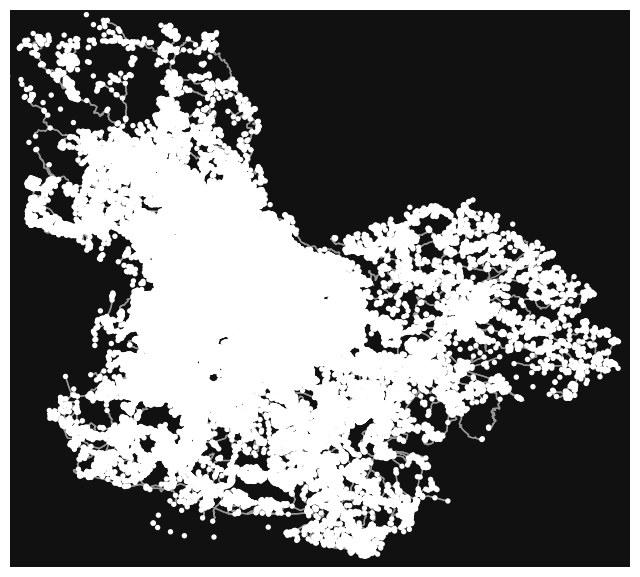

In [82]:
# Eliminar del grafo todos los links no válidos
G_snap.remove_edges_from(edges_remove)
fig, ax = ox.plot_graph(G_snap)
nodes_Gsnap, edges_Gsnap = ox.graph_to_gdfs(G_snap, nodes=True, edges=True)


In [83]:
nodes_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Nodes/nodes_base_snap.shp')
edges_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Edges/edges_base_snap.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## __Visum Nodes__

In [84]:
# NODES
visum_nodes = nodes_base.reset_index().copy()

visum_nodes["NodeNo"] = range(1, len(visum_nodes) + 1) #Renumerar NodeNo para tengan IDs de 1 a N (en vez de osmid)
visum_nodes["XCoord"] = visum_nodes.geometry.x
visum_nodes["YCoord"] = visum_nodes.geometry.y

# Dicc. de mapeo osmid a NodeNo para luego asignar fromNode/toNode a los edges
node_no_map = dict(zip(visum_nodes["osmid"], visum_nodes["NodeNo"]))
visum_nodes.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Nodes/nodes_visum.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## __Visum Edges__

In [85]:
# Tsys = WALK
walk_types = {
    'unclassified', 'residential', 'service'
    'footway', 'path', 'living_street', 'pedestrian', 'track', 'steps',
    'corridor', 'bridleway', 'ladder'}

#Tsys = CAR, BUS
car_types = {
    'motorway', 'motorway_link', 
    'trunk', 'trunk_link', 
    'primary', 'primary_link', 
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified', 'residential', 'service',
    }

# Tsys = BIKE
bicycle_types = {'cycleway'}

# Tsys = BRT
BRT_types = {'busway'}

# Tsys = TREN LIGERO
tren_ligero_names = {
    'Línea 1 del Tren Eléctrico Urbano',
    'Linea 1 del Tren Eléctrico Urbano', 
    'Línea 2 del Tren Eléctrico Urbano',
    'Linea 2 del Tren Eléctrico Urbano',
    'Línea 3 del Tren Eléctrico Urbano',
    'Linea 3 del Tren Eléctrico Urbano',
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara',
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara'
}

In [86]:
def get_tsys_set(row):
    highway = row.get('highway')
    name = row.get('name', '')
    # Códigos de sistema
    tsys_map = {'CAR': 'C', 'BUS': 'B', 'WALK': 'W', 'BICYCLE': 'Y', 'TREN LIGERO':'L'}

    #if highway is busway, assign BRT
    if highway == 'busway':
        return {tsys_map['TREN LIGERO']}
    
    #if name indicates tren ligero, assign TREN LIGERO
    # if name in tren_ligero_names:
    #     return {tsys_map['TREN LIGERO']}
    # Si name es lista, revisa si alguno está en tren_ligero_names
    if isinstance(name, list):
        if any(n in tren_ligero_names for n in name):
            return {tsys_map['TREN LIGERO']}
    else:
        if name in tren_ligero_names:
            return {tsys_map['TREN LIGERO']}
    
    if isinstance(highway, str):
        hw_list = [highway]
    elif isinstance(highway, list):
        hw_list = highway
    else:
        return set()
    
    tsys_set = set()
    if any(h in car_types for h in hw_list):
        tsys_set.add(tsys_map['CAR'])
        tsys_set.add(tsys_map['BUS'])
    if any(h in walk_types for h in hw_list):
        tsys_set.add(tsys_map['WALK'])
    if any(h in bicycle_types for h in hw_list):
        tsys_set.add(tsys_map['BICYCLE'])
    
    return tsys_set

In [87]:
def one_way_flag(row):
    # OSMnx drive graph is directed; use simple 1/0 export
    ow = row.get("oneway", None)
    if pd.isna(ow) or ow is None:
        return 0
    if isinstance(ow, bool):
        return int(ow)
    if str(ow).lower() in ["yes", "true", "1"]:
        return 1
    return 0

In [88]:
# EDGES
visum_links = edges_base.reset_index().copy()

# asignar fromNode/toNode usando el dicc. de mapeo
visum_links["FromNodeNo"] = visum_links["u"].map(node_no_map) 
visum_links["ToNodeNo"] = visum_links["v"].map(node_no_map)

# link no.
visum_links["LinkNo"] = range(1, len(visum_links) + 1) #Renumerar para tengan IDs de 1 a N (en vez de osmid)

# Allowed modes
visum_links['AllowedModes'] = visum_links.apply(get_tsys_set, axis=1)

# Length
METRIC_CRS = "EPSG:32613"
visum_links["Length_m"] = visum_links.to_crs(METRIC_CRS).length

# OneWay
visum_links["OneWay"] = visum_links.apply(one_way_flag, axis=1)
visum_links["Name"] = visum_links.get("name", None).apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
)

visum_links
visum_links.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/edges_visum.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'AllowedModes' to 'AllowedMod'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'OneWay' to 'OneWay_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Name' to 'Name_1'
  ogr_write(


## __Read Bus Stops__

In [99]:
stops_imeplan = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos IMEPLAN/Transporte Publico/amg_estategia_puntos_de_parada/AMG_estrategia_de_puntos_de_parada_de_transporte_publico_A04.shp')
stops_imeplan.head()

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,ruta_32,ruta_33,ruta_34,ruta_35,tipo,municipio,accion,etapa,dicts,geometry
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),El Salto,None,None,None,MULTIPOINT ((680976.456 2272736.641))
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Tonalá,None,None,None,MULTIPOINT ((681483.254 2280845.501))
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700561.553 2281164.022))
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700707.084 2281320.114))
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700907.289 2281378.235))


In [ ]:
# IMEPLAN stops EPSG: 32613 (metros)
print("original stops_imeplan CRS:", stops_imeplan.crs)

original stops_imeplan CRS: EPSG:32613


In [ ]:
print("original stops_imeplan CRS:", stops_imeplan.crs)
#stops_imeplan = stops_imeplan.to_crs(epsg=4326)
#print("stops_imeplan CRS after transformation:", stops_imeplan.crs)

original stops_imeplan CRS: EPSG:32613
stops_imeplan CRS after transformation: EPSG:4326


## __Snap Bus Stops to Link__

In [102]:
# 1) Copia y revisa tipos geométricos
bus_stops = stops_imeplan.copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 2) Convierte MultiPoint -> Point (una fila por punto)
bus_stops = bus_stops.explode(index_parts=False).reset_index(drop=True)
print(bus_stops.geom_type.value_counts(dropna=False))

# 3) Quédate solo con Point válidos
bus_stops = bus_stops[bus_stops.geometry.notna() & (bus_stops.geom_type == "Point")].copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 4) Extrae coordenadas
bus_stops["XCoord"] = bus_stops.geometry.x
bus_stops["YCoord"] = bus_stops.geometry.y
print(bus_stops[["XCoord", "YCoord"]].head())

MultiPoint    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
          XCoord        YCoord
0  680976.456130  2.272737e+06
1  681483.253691  2.280846e+06
2  700561.553323  2.281164e+06
3  700707.084499  2.281320e+06
4  700907.289266  2.281378e+06


## __Snap stop to nearest edge using G_snap (sin los links de walk)__

In [ ]:
# Reproyectar G_snap a EPSG: 4326 para que esté en la misma proyección que los puntos de parada
print("original G_snap CRS:", G_snap.graph['crs'])
G_snap = ox.project_graph(G_snap, to_crs="EPSG:32613")
print("G_snap CRS after reprojection:", G_snap.graph['crs'])

original G_snap CRS: epsg:4326
G_snap CRS after reprojection: EPSG:32613


In [106]:
snap_nodes_inM, snap_edges_inM = ox.graph_to_gdfs(G_snap, nodes=True, edges=True)
snap_nodes_inM.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Nodes/meters/nodes_snap_m.shp')
snap_edges_inM.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Edges/meters/edges_snap_m.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


In [103]:
# 5) Encuentra nodos más cercanos
nearest_nodes = ox.nearest_nodes(G_snap, bus_stops["XCoord"], bus_stops["YCoord"])

# 6) Encuentra edges más cercanas y distancias
nearest_edges, edge_distance = ox.nearest_edges(
    G_snap, X=bus_stops["XCoord"], Y=bus_stops["YCoord"], return_dist=True
)

bus_stops["NearestNodeOSM"] = nearest_nodes
bus_stops["NearestNodeNo"] = bus_stops["NearestNodeOSM"].map(node_no_map)
bus_stops["NearestEdge"] = list(nearest_edges) # nearest edge in (u,v,key) format (tupla)
bus_stops["SnapDist_m"] = edge_distance # si G_snap esta en 4326, esta en grados


In [104]:
WGS84 = "EPSG:4326"

# derive nearest link and relative position
nearest_link_nos = []
rel_positions = []
from_node_nos = []
to_node_nos = []
nearest_highways = []  # Nuevo: para guardar el highway del link

visum_links_geom = visum_links[["LinkNo", "u", "v", "key", "FromNodeNo", "ToNodeNo", "geometry", "highway"]].copy()
visum_links_geom = visum_links_geom.set_index(["u", "v", "key"])

for row in bus_stops.itertuples():
    e = row.NearestEdge #(u, v, key) tupla

    if e in visum_links_geom.index:
        rec = visum_links_geom.loc[e]
        line = rec.geometry
        p = row.geometry

        # relative position on directional link
        rel = 0.0
        try:
            #line_m = gpd.GeoSeries([line], crs=WGS84).to_crs(METRIC_CRS).iloc[0]
            #p_m = gpd.GeoSeries([p], crs=WGS84).to_crs(METRIC_CRS).iloc[0]
            #if line_m.length > 0:
               # rel = float(line_m.project(p_m) / line_m.length)
            if line.length > 0:
                rel = float(line.project(p) / line.length)
        except Exception:
            rel = 0.0

        nearest_link_nos.append(int(rec.LinkNo))
        rel_positions.append(rel)
        from_node_nos.append(int(rec.FromNodeNo))
        to_node_nos.append(int(rec.ToNodeNo))
        nearest_highways.append(rec.highway)  # Nuevo: highway del link
    else:
        nearest_link_nos.append(None)
        rel_positions.append(None)
        from_node_nos.append(None)
        to_node_nos.append(None)
        nearest_highways.append(None)  # Nuevo: highway es None si no hay match

bus_stops["NearestLinkNo"] = nearest_link_nos
bus_stops["RelPosOnLink"] = rel_positions
bus_stops["FromNodeNo"] = from_node_nos
bus_stops["ToNodeNo"] = to_node_nos
bus_stops["NearestLink_HighwayVal"] = nearest_highways  # Nuevo: highway del link

In [105]:
#bus_stops.drop(columns=["NearestNodeOSM", "NearestEdge", "SnapDist_m"], inplace=True)
bus_stops
bus_stops.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/SP (snapped including service)/meters/busStops_snapped_M.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeOSM' to 'NearestNod'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeNo' to 'NearestN_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestEdge' to 'NearestEdg'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLinkNo' to 'NearestLin'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'RelPosOnLink' to 'RelPosOnLi'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLink_HighwayVal' to 'NearestL_1'
  ogr_write(


In [95]:
bus_stops

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,YCoord,NearestNodeOSM,NearestNodeNo,NearestEdge,SnapDist_m,NearestLinkNo,RelPosOnLink,FromNodeNo,ToNodeNo,NearestLink_HighwayVal
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,20.544832,1771858665,3304,"(1771858665, 8778745267, 0)",0.000077,9238,0.116142,3304,30379,secondary
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,20.618022,1700484749,2340,"(1677124239, 1700484749, 0)",0.000076,4352,0.817699,1495,2340,primary
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,20.618956,8407044728,24811,"(8407044724, 8407044728, 0)",0.000065,65242,0.850051,24808,24811,residential
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,20.620351,1746083332,2947,"(8778413347, 1746083332, 0)",0.000098,77366,0.660487,30220,2947,secondary
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,20.620854,1746083335,2948,"(1746090115, 1746083335, 0)",0.000042,8384,0.595657,2997,2948,secondary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,20.610087,5987144952,16245,"(6322033098, 6322033110, 0)",0.000080,49413,0.110336,18239,18245,primary
12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,20.613537,8414023283,25555,"(6322039422, 8414023283, 0)",0.000016,49451,0.920860,18255,25555,primary
12515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,20.621700,1746083377,2959,"(1746083353, 1746083377, 0)",0.000020,8288,0.801377,2957,2959,secondary
12516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,20.624960,1746293814,3072,"(1746195132, 1746293814, 0)",0.000050,8511,0.772637,3047,3072,tertiary


In [96]:
bus_stops['NearestLink_HighwayVal'].value_counts(dropna=False)


NearestLink_HighwayVal
residential                     4930
tertiary                        3791
secondary                       1677
primary                         1259
service                          306
unclassified                     212
trunk                            202
trunk_link                        42
primary_link                      38
motorway_link                     16
tertiary_link                     14
secondary_link                    12
motorway                          12
[tertiary, secondary]              2
[secondary_link, secondary]        2
[residential, motorway_link]       1
[residential, trunk_link]          1
[tertiary, trunk_link]             1
Name: count, dtype: int64